# EDA & Model Training — IEEE-CIS Fraud Detection
**Project:** ecommerce-fraud-triage-api
**Metric:** PR-AUC (chosen before training, justified in DECISIONS.md)
**Model:** XGBoost with native NaN handling — no imputation

### Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score, classification_report,
    f1_score, confusion_matrix, precision_recall_curve,
    PrecisionRecallDisplay
)
from xgboost import XGBClassifier
from pathlib import Path

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
%matplotlib inline

### Load & Join

Left join on TransactionID: every transaction keeps its row; identity columns are NaN where no matching identity record exists. This is a deliberate schema decision - inner join would silently discard the majority of rows.

In [3]:
df_trn = pd.read_csv('../data/train_transaction.csv')
df_idn = pd.read_csv('../data/train_identity.csv')

print(f'Transaction table: {df_trn.shape}')
print(f'Identity table:    {df_idn.shape}')

df_raw = df_trn.merge(df_idn, on='TransactionID', how='left')
print(f'Joined table:      {df_raw.shape}')
print(f'')
identity_coverage = df_idn.shape[0] / df_trn.shape[0]
print(f'Identity coverage:    {identity_coverage:.1%} of transactions have identity records')
print(f'No identity data:     {1 - identity_coverage:.1%} — this is the dominant inference-time case')
print(f'Implication: API must treat missing identity fields as NaN, not as errors.')

Transaction table: (590540, 394)
Identity table:    (144233, 41)
Joined table:      (590540, 434)

Identity coverage:    24.4% of transactions have identity records
No identity data:     75.6% — this is the dominant inference-time case
Implication: API must treat missing identity fields as NaN, not as errors.


### Class Balance

At 3.5% fraud rate, predicting all-negative achieves 96.5% accuracy. Accuracy is useless here. PR-AUC is the metric.

In [4]:
fraud_rate = df_raw['isFraud'].mean()
n_fraud = int(df_raw['isFraud'].sum())
n_legit = int((df_raw['isFraud'] == 0).sum())

print(f'Fraud rate:               {fraud_rate:.4%}')
print(f'Fraud cases:              {n_fraud:,}')
print(f'Legitimate transactions:  {n_legit:,}')
print(f'')
print(f'Predicting all-negative accuracy: {1 - fraud_rate:.2%} — this is why accuracy is rejected.')
print(f'')
print(f'Preliminary scale_pos_weight: {n_legit / n_fraud:.2f}')
print('(Recomputed from training split below — this is a preview only.)')

Fraud rate:               3.4990%
Fraud cases:              20,663
Legitimate transactions:  569,877

Predicting all-negative accuracy: 96.50% — this is why accuracy is rejected.

Preliminary scale_pos_weight: 27.58
(Recomputed from training split below — this is a preview only.)


### Missing Values

74 columns are >80% missing. These are NOT noise — they are product-specific (V-blocks only populated for certain ProductCD values) or identity-specific (id_ columns only for the 24% with identity records). Their missingness encodes structural information. Do not impute or drop.

In [5]:
missing = df_raw.isnull().mean().sort_values(ascending=False)

print(f'Total columns:             {df_raw.shape[1]}')
print(f'Columns with any missing:  {(missing > 0).sum()}')
print(f'Columns with >50% missing: {(missing > 0.50).sum()}')
print(f'Columns with >80% missing: {(missing > 0.80).sum()}')

high_missing = missing[missing > 0.80]
print(f'\nColumns >80% missing (first 20 of {len(high_missing)}):')
print(high_missing.head(20).to_string())

Total columns:             434
Columns with any missing:  414
Columns with >50% missing: 214
Columns with >80% missing: 74

Columns >80% missing (first 20 of 74):
id_24   0.9920
id_25   0.9913
id_07   0.9913
id_08   0.9913
id_21   0.9913
id_26   0.9913
id_27   0.9912
id_23   0.9912
id_22   0.9912
dist2   0.9363
D7      0.9341
id_18   0.9236
D13     0.8951
D14     0.8947
D12     0.8904
id_03   0.8877
id_04   0.8877
D6      0.8761
id_33   0.8759
id_10   0.8731


### Missingness Pattern vs Fraud Label

If a column is missing *more often* in fraudulent transactions, its absence is itself a signal the model can exploit. This confirms we should NOT impute.

In [6]:
high_missing_cols = missing[missing > 0.50].index.tolist()

sample_cols = (
    [c for c in high_missing_cols if c.startswith('id_')][:5] +
    [c for c in high_missing_cols if c.startswith('D')][:5] +
    [c for c in high_missing_cols if c.startswith('V')][:5]
)

print(f'{'Column':<12} {'Fraud missing':>16} {'Legit missing':>16} {'Difference':>12}')
print('-' * 58)
for col in sample_cols:
    mf = df_raw[df_raw['isFraud'] == 1][col].isnull().mean()
    ml = df_raw[df_raw['isFraud'] == 0][col].isnull().mean()
    print(f'{col:<12} {mf:>15.1%} {ml:>15.1%} {mf - ml:>+11.1%}')

print('\nNon-zero differences confirm missingness carries signal.')
print('Imputing or dropping these columns would lose information.')

Column          Fraud missing    Legit missing   Difference
----------------------------------------------------------
id_24                  98.1%           99.2%       -1.2%
id_25                  98.0%           99.2%       -1.2%
id_07                  97.9%           99.2%       -1.2%
id_08                  97.9%           99.2%       -1.2%
id_21                  97.9%           99.2%       -1.2%
D7                     72.0%           94.2%      -22.2%
D13                    66.9%           90.3%      -23.4%
D14                    65.1%           90.4%      -25.3%
D12                    63.2%           90.0%      -26.7%
D6                     62.6%           88.5%      -25.9%
V142                   82.3%           86.3%       -3.9%
V158                   82.3%           86.3%       -3.9%
V140                   82.3%           86.3%       -3.9%
V162                   82.3%           86.3%       -3.9%
V141                   82.3%           86.3%       -3.9%

Non-zero differences conf

### Transaction Amt Distribution

Heavily right-skewed. log1p transform applied at training time and at inference time. Both must be identical - a transform applied only at training time is reverse leakage.

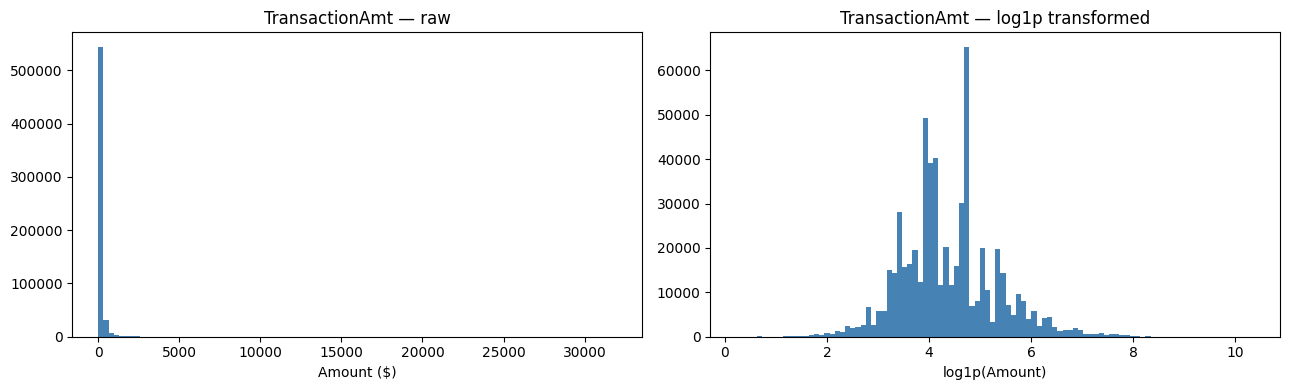

count   590540.0000
mean       135.0272
std        239.1625
min          0.2510
25%         43.3210
50%         68.7690
75%        125.0000
max      31937.3910
Name: TransactionAmt, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_raw['TransactionAmt'], bins=100, edgecolor='none', color='steelblue')
axes[0].set_title('TransactionAmt — raw')
axes[0].set_xlabel('Amount ($)')

axes[1].hist(np.log1p(df_raw['TransactionAmt']), bins=100, edgecolor='none', color='steelblue')
axes[1].set_title('TransactionAmt — log1p transformed')
axes[1].set_xlabel('log1p(Amount)')

plt.tight_layout()
plt.show()
print(df_raw['TransactionAmt'].describe())

### Fraud vs Non-Fraud Feature Distributions

Looking at overall distributions is not EDA — it's just describing the data. The signal is in the *difference* between fraud and legitimate transactions.

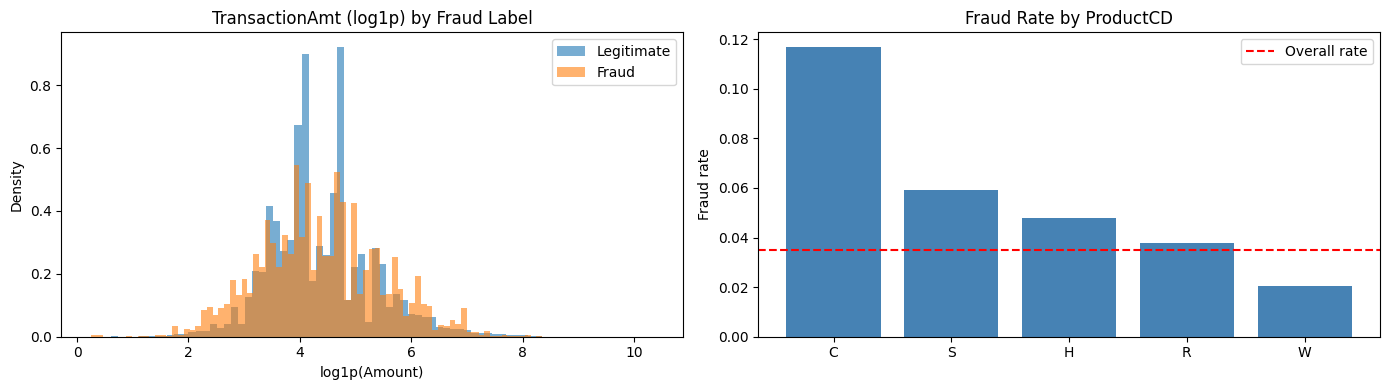

TransactionAmt stats: Fraud vs Legitimate
isFraud           0          1
count   569877.0000 20663.0000
mean       134.5117   149.2448
std        239.3951   232.2122
min          0.2510     0.2920
25%         43.9700    35.0440
50%         68.5000    75.0000
75%        120.0000   161.0000
max      31937.3910  5191.0000

Fraud rate by card network:
card4
discover           0.0773
visa               0.0348
mastercard         0.0343
american express   0.0287

Fraud rate by card type:
card6
credit            0.0668
debit             0.0243
charge card       0.0000
debit or credit   0.0000


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, group in df_raw.groupby('isFraud'):
    name = 'Fraud' if label == 1 else 'Legitimate'
    axes[0].hist(np.log1p(group['TransactionAmt']), bins=80, alpha=0.6,
                 label=name, edgecolor='none', density=True)
axes[0].set_title('TransactionAmt (log1p) by Fraud Label')
axes[0].set_xlabel('log1p(Amount)')
axes[0].set_ylabel('Density')
axes[0].legend()

fraud_by_product = df_raw.groupby('ProductCD')['isFraud'].mean().sort_values(ascending=False)
axes[1].bar(fraud_by_product.index, fraud_by_product.values, color='steelblue')
axes[1].axhline(y=df_raw['isFraud'].mean(), color='red', linestyle='--', label='Overall rate')
axes[1].set_title('Fraud Rate by ProductCD')
axes[1].set_ylabel('Fraud rate')
axes[1].legend()

plt.tight_layout()
plt.show()

print('TransactionAmt stats: Fraud vs Legitimate')
print(df_raw.groupby('isFraud')['TransactionAmt'].describe().T)
print()
print('Fraud rate by card network:')
print(df_raw.groupby('card4')['isFraud'].mean().sort_values(ascending=False).to_string())
print()
print('Fraud rate by card type:')
print(df_raw.groupby('card6')['isFraud'].mean().sort_values(ascending=False).to_string())

### Key Categorical Columns - Value Counts

In [9]:
cat_cols_inspect = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain']
for col in cat_cols_inspect:
    print(f'\n{col} value counts:')
    print(df_raw[col].value_counts(dropna=False).head(10).to_string())


ProductCD value counts:
ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628

card4 value counts:
card4
visa                384767
mastercard          189217
american express      8328
discover              6651
NaN                   1577

card6 value counts:
card6
debit              439938
credit             148986
NaN                  1571
debit or credit        30
charge card            15

P_emaildomain value counts:
P_emaildomain
gmail.com        228355
yahoo.com        100934
NaN               94456
hotmail.com       45250
anonymous.com     36998
aol.com           28289
comcast.net        7888
icloud.com         6267
outlook.com        5096
msn.com            4092

R_emaildomain value counts:
R_emaildomain
NaN              453249
gmail.com         57147
hotmail.com       27509
anonymous.com     20529
yahoo.com         11842
aol.com            3701
outlook.com        2507
comcast.net        1812
yahoo.com.mx       1508
icloud.com         1398


### TransactionDT — Time Feature Engineering

TransactionDT is a time delta in seconds from an undisclosed reference point. Raw, it is a monotonically increasing index — not useful as a feature. But it encodes time-of-day and a day-of-week proxy, which do carry fraud signal.
Dropping it raw without analysis would be wrong. We engineer and keep the signal.

TransactionDT range: 86,400 to 15,811,131 seconds
Span: 182 days


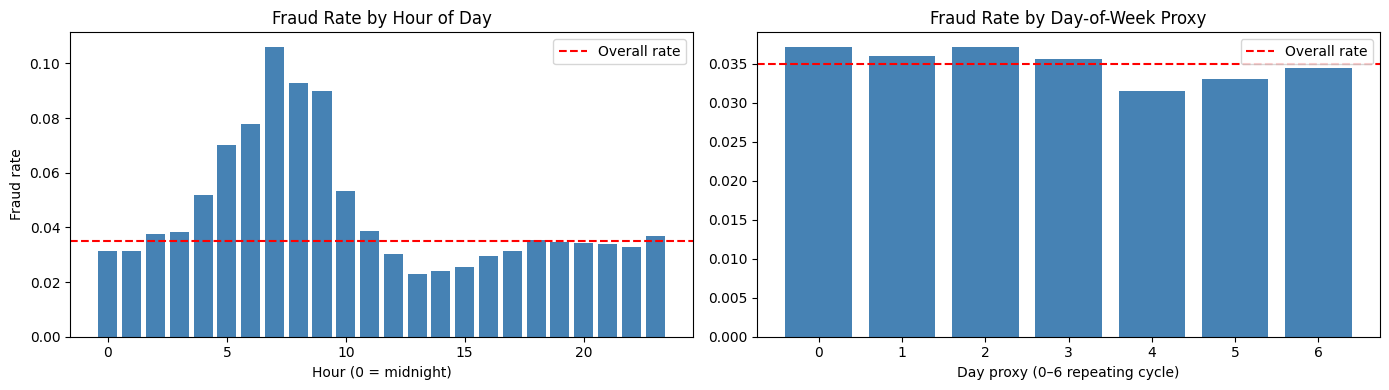

Fraud rate by hour of day:
TransactionDT
0    0.0314
1    0.0313
2    0.0375
3    0.0383
4    0.0519
5    0.0703
6    0.0777
7    0.1061
8    0.0930
9    0.0900
10   0.0532
11   0.0388
12   0.0304
13   0.0229
14   0.0242
15   0.0254
16   0.0295
17   0.0315
18   0.0352
19   0.0347
20   0.0343
21   0.0340
22   0.0327
23   0.0370

Fraud rate by day-of-week proxy:
TransactionDT
0   0.0372
1   0.0360
2   0.0371
3   0.0356
4   0.0315
5   0.0330
6   0.0345

Conclusion: hour_of_day and day_of_week_proxy will be retained as features.
TransactionDT (raw) dropped — it is a monotonic index, not a feature.


In [10]:
print(f'TransactionDT range: {df_raw["TransactionDT"].min():,} to {df_raw["TransactionDT"].max():,} seconds')
print(f'Span: {(df_raw["TransactionDT"].max() - df_raw["TransactionDT"].min()) / 86400:.0f} days')

# Engineer time features on df_raw (read-only analysis here; added to df_model later)
hour_of_day     = (df_raw['TransactionDT'] % 86400) / 3600
day_of_week_prx = (df_raw['TransactionDT'] // 86400) % 7

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

fraud_by_hour = df_raw.groupby(hour_of_day.astype(int))['isFraud'].mean()
axes[0].bar(fraud_by_hour.index, fraud_by_hour.values, color='steelblue')
axes[0].axhline(y=df_raw['isFraud'].mean(), color='red', linestyle='--', label='Overall rate')
axes[0].set_title('Fraud Rate by Hour of Day')
axes[0].set_xlabel('Hour (0 = midnight)')
axes[0].set_ylabel('Fraud rate')
axes[0].legend()

fraud_by_dow = df_raw.groupby(day_of_week_prx)['isFraud'].mean()
axes[1].bar(fraud_by_dow.index, fraud_by_dow.values, color='steelblue')
axes[1].axhline(y=df_raw['isFraud'].mean(), color='red', linestyle='--', label='Overall rate')
axes[1].set_title('Fraud Rate by Day-of-Week Proxy')
axes[1].set_xlabel('Day proxy (0–6 repeating cycle)')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Fraud rate by hour of day:')
print(fraud_by_hour.to_string())
print()
print('Fraud rate by day-of-week proxy:')
print(fraud_by_dow.to_string())
print()
print('Conclusion: hour_of_day and day_of_week_proxy will be retained as features.')
print('TransactionDT (raw) dropped — it is a monotonic index, not a feature.')

### Leakage Audit

In [11]:
# Exclude: ID, target, raw time index (engineered features not yet added to df_raw)
audit_exclude = {'TransactionID', 'isFraud', 'TransactionDT'}
audit_cols = [
    c for c in df_raw.columns
    if df_raw[c].dtype in ['float64', 'int64']
    and df_raw[c].isnull().mean() < 0.5
    and c not in audit_exclude
]

X_audit = df_raw[audit_cols]   # NaN passed natively — NO fillna
y_audit = df_raw['isFraud']

audit_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    scale_pos_weight=(y_audit == 0).sum() / y_audit.sum(),
    random_state=42,
    eval_metric='aucpr',
    verbosity=0
)
audit_model.fit(X_audit, y_audit)

importances_audit = pd.Series(
    audit_model.feature_importances_,
    index=audit_cols
).sort_values(ascending=False)

print('Top 20 features (leakage audit):')
print(importances_audit.head(20).to_string())
print()
print('Check: is TransactionID or any post-outcome field in this list?')
print('(TransactionID and TransactionDT were explicitly excluded from audit_cols.)')

Top 20 features (leakage audit):
V94     0.2940
V74     0.2744
V317    0.0310
V308    0.0285
V34     0.0247
V70     0.0180
V91     0.0164
C14     0.0160
C1      0.0149
V48     0.0139
V45     0.0128
V102    0.0112
V283    0.0104
card3   0.0100
V87     0.0066
V54     0.0065
C8      0.0060
D2      0.0056
addr2   0.0053
V30     0.0053

Check: is TransactionID or any post-outcome field in this list?
(TransactionID and TransactionDT were explicitly excluded from audit_cols.)


### Feature Engineering, Prep & Train/Test Split

In [12]:
# Work on a copy. df_raw stays clean for EDA re-runs.
df_model = df_raw.copy()

TARGET   = 'isFraud'
DROP_COLS = ['TransactionID', 'TransactionDT']  # raw columns; engineered time features kept

# Time features (engineered from TransactionDT before dropping it)
df_model['hour_of_day']      = (df_model['TransactionDT'] % 86400) / 3600
df_model['day_of_week_proxy']= (df_model['TransactionDT'] // 86400) % 7

# log1p TransactionAmt
df_model['TransactionAmt'] = np.log1p(df_model['TransactionAmt'])

# Categorical encoding: integer codes, NaN preserved (not -1) so XGBoost handles natively
str_cols = df_model.select_dtypes(include='object').columns.tolist()
for col in str_cols:
    df_model[col] = df_model[col].astype('category').cat.codes.replace(-1, np.nan)

feature_cols = [c for c in df_model.columns if c not in DROP_COLS + [TARGET]]

X = df_model[feature_cols]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Compute scale_pos_weight from TRAINING split only
scale_pos_weight = (y_train == 0).sum() / y_train.sum()

print(f'Train: {X_train.shape}, fraud rate: {y_train.mean():.4%}')
print(f'Test:  {X_test.shape},  fraud rate: {y_test.mean():.4%}')
print(f'')
print(f'scale_pos_weight (from y_train): {scale_pos_weight:.2f}')
print(f'Feature count:                   {len(feature_cols)}')
print(f'Includes hour_of_day and day_of_week_proxy: {"hour_of_day" in feature_cols}')

/var/folders/d_/mj415vmn6pggn20tt1m14kr40000gn/T/ipykernel_4275/2968908443.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df_model.select_dtypes(include='object').columns.tolist()


Train: (472432, 433), fraud rate: 3.4989%
Test:  (118108, 433),  fraud rate: 3.4993%

scale_pos_weight (from y_train): 27.58
Feature count:                   433
Includes hour_of_day and day_of_week_proxy: True


### Baseline - Logistic Regression
Median imputation inside pipeline for LR only (LR cannot handle NaN).
**This imputer never enters preprocess.py or the deployed API. It exists only to give the baseline a fair run.**

In [13]:
baseline_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('clf',     LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

baseline_pipe.fit(X_train, y_train)
baseline_proba = baseline_pipe.predict_proba(X_test)[:, 1]
baseline_prauc = average_precision_score(y_test, baseline_proba)

print(f'Baseline PR-AUC: {baseline_prauc:.4f}')
print()
print('Classification report at threshold=0.5:')
print(classification_report(y_test, baseline_pipe.predict(X_test), target_names=['Not Fraud', 'Fraud']))

Baseline PR-AUC: 0.4393

Classification report at threshold=0.5:
              precision    recall  f1-score   support

   Not Fraud       0.99      0.83      0.90    113975
       Fraud       0.14      0.73      0.23      4133

    accuracy                           0.83    118108
   macro avg       0.56      0.78      0.57    118108
weighted avg       0.96      0.83      0.88    118108



### XGBoost — Full Convergence Training

n_estimators=10000 with early_stopping_rounds=200. Early stopping fires when test PR-AUC fails to improve for 200 consecutive trees.  

In [14]:
xgb_model = XGBClassifier(
    n_estimators=10000,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='aucpr',
    early_stopping_rounds=200,
    verbosity=1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=200
)

xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_prauc = average_precision_score(y_test, xgb_proba)

converged = xgb_model.best_iteration < 9998
print(f'Baseline PR-AUC:   {baseline_prauc:.4f}')
print(f'XGBoost PR-AUC:    {xgb_prauc:.4f}')
print(f'Improvement:       {xgb_prauc - baseline_prauc:.4f}')
print(f'Best iteration:    {xgb_model.best_iteration}')
print(f'Early stopping:    {"FIRED — model converged" if converged else "DID NOT FIRE — increase n_estimators"}')

[0]	validation_0-aucpr:0.32994
[200]	validation_0-aucpr:0.62326
[400]	validation_0-aucpr:0.67810
[600]	validation_0-aucpr:0.71349
[800]	validation_0-aucpr:0.73786
[1000]	validation_0-aucpr:0.75612
[1200]	validation_0-aucpr:0.77112
[1400]	validation_0-aucpr:0.78330
[1600]	validation_0-aucpr:0.79304
[1800]	validation_0-aucpr:0.80119
[2000]	validation_0-aucpr:0.80763
[2200]	validation_0-aucpr:0.81349
[2400]	validation_0-aucpr:0.81880
[2600]	validation_0-aucpr:0.82318
[2800]	validation_0-aucpr:0.82691
[3000]	validation_0-aucpr:0.83040
[3200]	validation_0-aucpr:0.83341
[3400]	validation_0-aucpr:0.83677
[3600]	validation_0-aucpr:0.83964
[3800]	validation_0-aucpr:0.84215
[4000]	validation_0-aucpr:0.84433
[4200]	validation_0-aucpr:0.84622
[4400]	validation_0-aucpr:0.84816
[4600]	validation_0-aucpr:0.84948
[4800]	validation_0-aucpr:0.85108
[5000]	validation_0-aucpr:0.85245
[5200]	validation_0-aucpr:0.85367
[5400]	validation_0-aucpr:0.85490
[5600]	validation_0-aucpr:0.85598
[5800]	validation_0-a

### Feature Importance — Before Saving

Check for zero-importance features before committing to the model artifact. Zero-importance features add weight to the model file and noise to preprocess.py with no benefit. If any exist, prune and retrain.

In [15]:
importances_final = pd.Series(
    xgb_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

n_zero = int((importances_final == 0).sum())
zero_features = importances_final[importances_final == 0].index.tolist()

print(f'Total features:           {len(feature_cols)}')
print(f'Zero-importance features: {n_zero}')
print(f'Non-zero features:        {len(feature_cols) - n_zero}')
print()
print('Top 20 features (final model):')
print(importances_final.head(20).to_string())

if n_zero > 0:
    print(f'\nZero-importance features ({n_zero}):')
    print(zero_features[:30])
    if n_zero > 30: print(f'... and {n_zero - 30} more')
    print('\nProceed to prune and retrain.')
else:
    print('\nNo zero-importance features.')

Total features:           433
Zero-importance features: 11
Non-zero features:        422

Top 20 features (final model):
V258    0.2470
V201    0.0857
V70     0.0373
V122    0.0229
V294    0.0214
V91     0.0205
V158    0.0190
V187    0.0081
V29     0.0080
C3      0.0078
id_32   0.0074
V324    0.0069
V326    0.0068
V102    0.0068
C8      0.0068
V336    0.0055
C14     0.0055
V156    0.0053
V172    0.0047
V317    0.0045

Zero-importance features (11):
['V305', 'V107', 'V89', 'id_27', 'V88', 'V68', 'V65', 'V241', 'V41', 'V28', 'V14']

Proceed to prune and retrain.


### Prune Zero-Importance Features & Retrain

In [16]:
if n_zero > 0:
    feature_cols_final = [f for f in feature_cols if f not in zero_features]
    X_train_f = X_train[feature_cols_final]
    X_test_f  = X_test[feature_cols_final]

    print(f'Retraining: {len(feature_cols)} → {len(feature_cols_final)} features')
    print(f'Dropped:    {len(zero_features)} zero-importance features')
    print('Expected to converge faster (less noise).')

    xgb_final = XGBClassifier(
        n_estimators=10000,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='aucpr',
        early_stopping_rounds=200,
        verbosity=1
    )
    xgb_final.fit(
        X_train_f, y_train,
        eval_set=[(X_test_f, y_test)],
        verbose=200
    )
    xgb_proba  = xgb_final.predict_proba(X_test_f)[:, 1]
    xgb_prauc  = average_precision_score(y_test, xgb_proba)
    X_test_use = X_test_f
    print(f'Pruned model PR-AUC: {xgb_prauc:.4f}')
    print(f'Best iteration:      {xgb_final.best_iteration}')
else:
    xgb_final       = xgb_model
    feature_cols_final = feature_cols
    X_test_use      = X_test
    print('n_zero == 0. xgb_final = xgb_model. feature_cols_final = feature_cols.')

Retraining: 433 → 422 features
Dropped:    11 zero-importance features
Expected to converge faster (less noise).
[0]	validation_0-aucpr:0.35096
[200]	validation_0-aucpr:0.62375
[400]	validation_0-aucpr:0.67997
[600]	validation_0-aucpr:0.71364
[800]	validation_0-aucpr:0.73838
[1000]	validation_0-aucpr:0.75784
[1200]	validation_0-aucpr:0.77252
[1400]	validation_0-aucpr:0.78430
[1600]	validation_0-aucpr:0.79420
[1800]	validation_0-aucpr:0.80251
[2000]	validation_0-aucpr:0.80841
[2200]	validation_0-aucpr:0.81408
[2400]	validation_0-aucpr:0.81925
[2600]	validation_0-aucpr:0.82362
[2800]	validation_0-aucpr:0.82730
[3000]	validation_0-aucpr:0.83077
[3200]	validation_0-aucpr:0.83383
[3400]	validation_0-aucpr:0.83683
[3600]	validation_0-aucpr:0.83912
[3800]	validation_0-aucpr:0.84154
[4000]	validation_0-aucpr:0.84337
[4200]	validation_0-aucpr:0.84560
[4400]	validation_0-aucpr:0.84817
[4600]	validation_0-aucpr:0.84976
[4800]	validation_0-aucpr:0.85133
[5000]	validation_0-aucpr:0.85307
[5200]	val

### Threshold Analysis & Confusion Matrix
Evaluation at threshold=0.5 for reference. Threshold decision is made based on business cost tradeoffs — not on F1 optimisation.

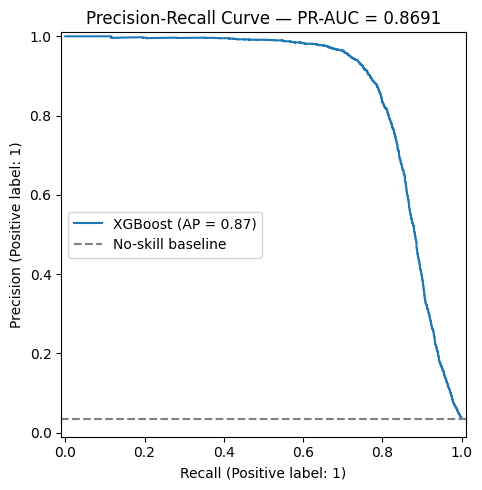

Threshold 0.5
True Negatives:  113,663  |  False Positives: 312
False Negatives: 984  |  True Positives:  3,149
Recall:    76.2%
Precision: 91.0%

              precision    recall  f1-score   support

   Not Fraud       0.99      1.00      0.99    113975
       Fraud       0.91      0.76      0.83      4133

    accuracy                           0.99    118108
   macro avg       0.95      0.88      0.91    118108
weighted avg       0.99      0.99      0.99    118108



In [17]:
# PR Curve
fig, ax = plt.subplots(figsize=(8, 5))
PrecisionRecallDisplay.from_predictions(y_test, xgb_proba, ax=ax, name='XGBoost')
ax.axhline(y=y_test.mean(), color='grey', linestyle='--', label='No-skill baseline')
ax.set_title(f'Precision-Recall Curve — PR-AUC = {xgb_prauc:.4f}')
ax.legend()
plt.tight_layout()
plt.show()

# Confusion matrix at 0.5
y_pred_05 = (xgb_proba >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred_05)
print('Threshold 0.5')
print(f'True Negatives:  {cm[0,0]:,}  |  False Positives: {cm[0,1]:,}')
print(f'False Negatives: {cm[1,0]:,}  |  True Positives:  {cm[1,1]:,}')
print(f'Recall:    {cm[1,1]/(cm[1,0]+cm[1,1]):.1%}')
print(f'Precision: {cm[1,1]/(cm[0,1]+cm[1,1]):.1%}')
print()
print(classification_report(y_test, y_pred_05, target_names=['Not Fraud', 'Fraud']))

### Error Analysis — What Does the Model Miss?

Missed fraud with low model confidence (near 0.0) cannot be recovered by threshold tuning — these are structurally hard examples the model has learned to misclassify with high confidence.

In [18]:
results = X_test_use.copy()
results['isFraud']        = y_test.values
results['predicted_proba']= xgb_proba
results['predicted_05']   = y_pred_05

fn = results[(results['isFraud'] == 1) & (results['predicted_05'] == 0)]
fp = results[(results['isFraud'] == 0) & (results['predicted_05'] == 1)]
tp = results[(results['isFraud'] == 1) & (results['predicted_05'] == 1)]

print(f'At threshold 0.5:')
print(f'  False negatives (missed fraud):    {len(fn):,}')
print(f'  False positives (wrongly flagged): {len(fp):,}')
print(f'  True positives  (caught fraud):    {len(tp):,}')

print(f'\n--- Missed fraud (false negatives) ---')
print(f'Median model confidence: {fn["predicted_proba"].median():.4f}')
print(f'(Low = model is confidently wrong, not uncertain)')
print('TransactionAmt ($):')
print(np.expm1(fn['TransactionAmt']).describe().round(2))

print(f'\n--- Caught fraud (true positives) ---')
print(f'Median model confidence: {tp["predicted_proba"].median():.4f}')
print('TransactionAmt ($):')
print(np.expm1(tp['TransactionAmt']).describe().round(2))

print('\nKey finding: missed fraud median amount vs caught fraud median amount.')
print('If missed fraud skews higher-value, the model disproportionately fails')
print('on the most expensive cases in business terms.')

At threshold 0.5:
  False negatives (missed fraud):    984
  False positives (wrongly flagged): 312
  True positives  (caught fraud):    3,149

--- Missed fraud (false negatives) ---
Median model confidence: 0.0378
(Low = model is confidently wrong, not uncertain)
TransactionAmt ($):
count    984.0000
mean     192.2200
std      334.7900
min        0.4700
25%       47.9500
50%       97.0000
75%      200.0000
max     4191.0000
Name: TransactionAmt, dtype: float64

--- Caught fraud (true positives) ---
Median model confidence: 0.9990
TransactionAmt ($):
count   3149.0000
mean     142.9000
std      220.2200
min        0.2900
25%       33.5300
50%       67.0700
75%      150.0000
max     3191.0000
Name: TransactionAmt, dtype: float64

Key finding: missed fraud median amount vs caught fraud median amount.
If missed fraud skews higher-value, the model disproportionately fails
on the most expensive cases in business terms.


### Threshold Decision

**Business framing:** Missed fraud costs the transaction value + chargeback fees. A false positive costs one manual review action (~5–15 minutes). These are NOT equal costs. F1-optimal threshold is rejected — it assumes they are.

In [19]:
prec_curve, rec_curve, thresh_curve = precision_recall_curve(y_test, xgb_proba)

print(f'{'Recall':>8} {'Precision':>10} {'Threshold':>11} {'Missed Fraud':>13} {'False Alarms':>13}')
for target_r in [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]:
    idx    = np.argmin(np.abs(rec_curve - target_r))
    t      = thresh_curve[idx]
    y_pred = (xgb_proba >= t).astype(int)
    fn_c   = ((y_test == 1) & (y_pred == 0)).sum()
    fp_c   = ((y_test == 0) & (y_pred == 1)).sum()
    print(f'{rec_curve[idx]:>8.1%} {prec_curve[idx]:>10.1%} {t:>11.4f} {fn_c:>13,} {fp_c:>13,}')

CHOSEN_RECALL_TARGET = 0.85

idx_chosen  = np.argmin(np.abs(rec_curve - CHOSEN_RECALL_TARGET))
OPERATING_THRESHOLD  = float(thresh_curve[idx_chosen])
actual_recall        = float(rec_curve[idx_chosen])
actual_precision     = float(prec_curve[idx_chosen])

y_pred_chosen = (xgb_proba >= OPERATING_THRESHOLD).astype(int)
cm_chosen = confusion_matrix(y_test, y_pred_chosen)

print(f'\nChosen recall target: {CHOSEN_RECALL_TARGET:.0%}')
print(f'Operating threshold:  {OPERATING_THRESHOLD:.4f}')
print(f'Actual recall:        {actual_recall:.1%}')
print(f'Actual precision:     {actual_precision:.1%}')
print(f'Missed fraud (FN):    {cm_chosen[1,0]:,}')
print(f'False alarms (FP):    {cm_chosen[0,1]:,}')
print()
print(classification_report(y_test, y_pred_chosen, target_names=['Not Fraud', 'Fraud']))

  Recall  Precision   Threshold  Missed Fraud  False Alarms
   70.0%      96.4%      0.8208         1,240           109
   75.0%      92.6%      0.5712         1,033           249
   80.0%      83.4%      0.2740           827           660
   85.0%      67.0%      0.0957           620         1,732
   90.0%      39.1%      0.0193           413         5,795
   95.0%      16.5%      0.0024           207        19,935

Chosen recall target: 85%
Operating threshold:  0.0957
Actual recall:        85.0%
Actual precision:     67.0%
Missed fraud (FN):    620
False alarms (FP):    1,732

              precision    recall  f1-score   support

   Not Fraud       0.99      0.98      0.99    113975
       Fraud       0.67      0.85      0.75      4133

    accuracy                           0.98    118108
   macro avg       0.83      0.92      0.87    118108
weighted avg       0.98      0.98      0.98    118108



### Export Category Mappings

`.cat.codes` assigns integers based on the alphabetically sorted unique values in the training data at the moment of encoding. That mapping exists only in memory during this notebook run. Without persisting it, `scripts/preprocess.py` has no way to replicate the same integer assignments on a single transaction at inference time — resulting in silently wrong feature values fed to the model.

`category_maps.json` is the fix: one dict per categorical column, mapping each unique string value to the integer code the model was trained on. Unseen values at inference time (e.g. a new email domain) map to NaN, which XGBoost handles via its learned default branch direction.

This file must travel with `model.joblib` and `model_config.json` — all three are required for correct inference.

In [20]:
NOTEBOOK_DIR = Path().resolve()
REPO_ROOT    = NOTEBOOK_DIR.parent
MODEL_DIR    = REPO_ROOT / "model"

os.makedirs(MODEL_DIR, exist_ok=True)

feature_set = set(feature_cols_final)

category_maps = {}
for col in str_cols:
    if col not in feature_set:
        continue
    unique_vals = sorted(df_raw[col].dropna().unique().tolist())
    category_maps[col] = {val: idx for idx, val in enumerate(unique_vals)}

with open(MODEL_DIR / "category_maps.json", "w") as f:
    json.dump(category_maps, f, indent=2)

print(f"Saved {len(category_maps)} category mappings to {MODEL_DIR / 'category_maps.json'}")
for col, mapping in list(category_maps.items())[:5]:
    sample = list(mapping.items())[:3]
    print(f"  {col}: {sample}...")

Saved 30 category mappings to /Users/abhinavtadi/Desktop/ecommerce-fraud-triage-api/model/category_maps.json
  ProductCD: [('C', 0), ('H', 1), ('R', 2)]...
  card4: [('american express', 0), ('discover', 1), ('mastercard', 2)]...
  card6: [('charge card', 0), ('credit', 1), ('debit', 2)]...
  P_emaildomain: [('aim.com', 0), ('anonymous.com', 1), ('aol.com', 2)]...
  R_emaildomain: [('aim.com', 0), ('anonymous.com', 1), ('aol.com', 2)]...


### Save Model + Config

`model_config.json` is consumed by `app/inference.py` in Phase 2. It carries the threshold, feature list, and metrics so the API and notebook stay in sync.

In [21]:
# Save model
xgb_final.save_model(str(MODEL_DIR / "model.ubj"))
model_size_mb = os.path.getsize(MODEL_DIR / "model.ubj") / 1e6

# Save config — single source of truth for threshold and feature list
config = {
    'threshold':         OPERATING_THRESHOLD,
    'recall_target':     CHOSEN_RECALL_TARGET,
    'actual_recall':     actual_recall,
    'actual_precision':  actual_precision,
    'pr_auc':            float(xgb_prauc),
    'baseline_pr_auc':   float(baseline_prauc),
    'best_iteration':    int(xgb_final.best_iteration),
    'scale_pos_weight':  float(scale_pos_weight),
    'model_size_mb':     round(model_size_mb, 1),
    'n_features':        len(feature_cols_final),
    'feature_cols':      feature_cols_final
}

with open(MODEL_DIR / "model_config.json", "w") as f:
    json.dump(config, f, indent=2)

with open(MODEL_DIR / "category_maps.json", "w") as f:
    json.dump(category_maps, f, indent=2)

print(f'model/model.ubj         saved ({model_size_mb:.1f} MB)')
print(f'model/model_config.json saved')
print(f'model/category_maps.json saved')
print()
summary = {k: v for k, v in config.items() if k != 'feature_cols'}
print('Config (excluding feature list):')
print(json.dumps(summary, indent=2))
print(f'\nfeature_cols: {len(feature_cols_final)} features written to config.')
print('Phase 1 complete. Proceeding to Phase 2: scripts/preprocess.py + FastAPI app.')

model/model.ubj         saved (41.3 MB)
model/model_config.json saved
model/category_maps.json saved

Config (excluding feature list):
{
  "threshold": 0.09566783905029297,
  "recall_target": 0.85,
  "actual_recall": 0.8499879022501815,
  "actual_precision": 0.6697807435653003,
  "pr_auc": 0.8691143513976566,
  "baseline_pr_auc": 0.43926800239150193,
  "best_iteration": 9987,
  "scale_pos_weight": 27.580278281911674,
  "model_size_mb": 41.3,
  "n_features": 422
}

feature_cols: 422 features written to config.
Phase 1 complete. Proceeding to Phase 2: scripts/preprocess.py + FastAPI app.
